# DistilBERT model za klasifikaciju emocija

## Učitavanje biblioteka i podešavanje okruženja

In [5]:
import random

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from data_reader import (
    get_training_data,
    get_validation_data,
    get_test_data
)

In [6]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


## Učitavanje i priprema podataka

In [7]:
LABEL_TO_ID = {
    "anger": 0,
    "fear": 1,
    "joy": 2,
    "love": 3,
    "sadness": 4,
    "surprise": 5
}

ID_TO_LABEL = {
    label_id: label
    for label, label_id in LABEL_TO_ID.items()
}

NUM_LABELS = len(LABEL_TO_ID)

In [9]:
def encode_labels(data):
    data = data.copy()
    data["label"] = data["emotion"].map(LABEL_TO_ID)
    return data


train_data = encode_labels(get_training_data())
val_data = encode_labels(get_validation_data())
test_data = encode_labels(get_test_data())

print(f"Trening:    {len(train_data):>5} primera")
print(f"Validacija: {len(val_data):>5} primera")
print(f"Test:       {len(test_data):>5} primera")
print()
print("Klase:", LABEL_TO_ID)

train_data.head()

Trening:    15983 primera
Validacija:  1997 primera
Test:        2000 primera

Klase: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


,text,emotion,label
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0


## DistilBERT tokenizer

In [10]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128

tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [11]:
example_text = train_data.iloc[0]["text"]

tokens = tokenizer.tokenize(example_text)

print("Originalna rečenica:")
print(example_text)

print("\nTokeni:")
print(tokens)

Originalna rečenica:
i didnt feel humiliated

Tokeni:
['i', 'didn', '##t', 'feel', 'humiliated']


In [12]:
class EmotionDataset(Dataset):

    def __init__(self, data, tokenizer, max_length):
        self.texts = data["text"].tolist()
        self.labels = data["label"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        encoded = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded["attention_mask"].squeeze(0),
            "label": torch.tensor(label, dtype=torch.long)
        }

In [13]:
train_dataset = EmotionDataset(
    train_data,
    tokenizer,
    MAX_LENGTH
)

val_dataset = EmotionDataset(
    val_data,
    tokenizer,
    MAX_LENGTH
)

test_dataset = EmotionDataset(
    test_data,
    tokenizer,
    MAX_LENGTH
)

In [14]:
sample = train_dataset[0]

print("Input IDs shape:", sample["input_ids"].shape)
print("Attention mask shape:", sample["attention_mask"].shape)
print("Label:", sample["label"].item())
print("Emotion:", train_data.iloc[0]["emotion"])

Input IDs shape: torch.Size([128])
Attention mask shape: torch.Size([128])
Label: 4
Emotion: sadness


## DataLoader

In [15]:
def create_data_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [16]:
train_loader, val_loader, test_loader = create_data_loaders(
    batch_size=16
)

batch = next(iter(train_loader))

print("Input IDs batch shape:", batch["input_ids"].shape)
print("Attention mask batch shape:", batch["attention_mask"].shape)
print("Labels batch shape:", batch["label"].shape)

Input IDs batch shape: torch.Size([16, 128])
Attention mask batch shape: torch.Size([16, 128])
Labels batch shape: torch.Size([16])


## DistilBERT model

In [17]:
def create_model():
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=ID_TO_LABEL,
        label2id=LABEL_TO_ID
    )

    return model.to(device)

In [18]:
model = create_model()

print(model.classifier)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Linear(in_features=768, out_features=6, bias=True)


## Provera prolaska jednog batch-a kroz model

In [19]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["label"].to(device)

with torch.no_grad():
    outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        labels=labels
    )

print("Loss:", outputs.loss.item())
print("Logits shape:", outputs.logits.shape)

Loss: 1.7813524007797241
Logits shape: torch.Size([16, 6])


In [20]:
predictions = torch.argmax(
    outputs.logits,
    dim=1
)

first_prediction = predictions[0].item()
first_label = labels[0].item()

print("Predicted:", ID_TO_LABEL[first_prediction])
print("Actual:", ID_TO_LABEL[first_label])

Predicted: joy
Actual: sadness


## Trening i validacija

Model se trenira na trening skupu, dok se nakon svake epohe evaluira na validation skupu.

Za poređenje konfiguracija prate se:
- Accuracy
- Macro F1

Najbolji checkpoint bira se prema najvećem validation Macro F1 rezultatu.

In [21]:
def train_epoch(model, data_loader, optimizer, device):
    model.train()

    total_loss = 0
    all_predictions = []
    all_labels = []

    for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()
        optimizer.step()

        predictions = torch.argmax(logits, dim=1)

        total_loss += loss.item()

        all_predictions.extend(
            predictions.detach().cpu().tolist()
        )

        all_labels.extend(
            labels.detach().cpu().tolist()
        )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return average_loss, accuracy, macro_f1

In [22]:
def validate(model, data_loader, device):
    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            predictions = torch.argmax(
                logits,
                dim=1
            )

            total_loss += loss.item()

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

    average_loss = total_loss / len(data_loader)

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return average_loss, accuracy, macro_f1

## Trening jedne konfiguracije

In [24]:
def train_configuration(
    learning_rate,
    batch_size,
    epochs
):
    train_loader, val_loader, _ = create_data_loaders(
        batch_size
    )

    model = create_model()

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate
    )

    best_validation_f1 = -1
    best_validation_accuracy = 0
    best_epoch = 0
    best_model_state = None

    history = []

    for epoch in range(epochs):
        train_loss, train_accuracy, train_macro_f1 = train_epoch(
            model,
            train_loader,
            optimizer,
            device
        )

        val_loss, val_accuracy, val_macro_f1 = validate(
            model,
            val_loader,
            device
        )

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "train_macro_f1": train_macro_f1,
            "val_loss": val_loss,
            "val_accuracy": val_accuracy,
            "val_macro_f1": val_macro_f1
        })

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train loss: {train_loss:.4f}, "
            f"train acc: {train_accuracy:.4f}, "
            f"train F1: {train_macro_f1:.4f} | "
            f"val loss: {val_loss:.4f}, "
            f"val acc: {val_accuracy:.4f}, "
            f"val F1: {val_macro_f1:.4f}"
        )

        if val_macro_f1 > best_validation_f1:
            best_validation_f1 = val_macro_f1
            best_validation_accuracy = val_accuracy
            best_epoch = epoch + 1

            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

    return {
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": epochs,
        "best_epoch": best_epoch,
        "validation_accuracy": best_validation_accuracy,
        "validation_macro_f1": best_validation_f1,
        "history": history,
        "model_state": best_model_state
    }

## Podešavanje hiperparametara

Testira se više kombinacija learning rate-a i batch size-a.

Najbolja konfiguracija bira se prema najvećem validation Macro F1 rezultatu.

In [25]:
EXPERIMENTS = [
    {
        "learning_rate": 2e-5,
        "batch_size": 16,
        "epochs": 3
    },
    {
        "learning_rate": 3e-5,
        "batch_size": 16,
        "epochs": 3
    },
    {
        "learning_rate": 5e-5,
        "batch_size": 16,
        "epochs": 3
    },
    {
        "learning_rate": 2e-5,
        "batch_size": 32,
        "epochs": 3
    }
]

In [26]:
experiment_results = []

best_result = None

for experiment_index, experiment in enumerate(EXPERIMENTS, start=1):

    print("\n" + "=" * 70)

    print(
        f"Experiment {experiment_index}/{len(EXPERIMENTS)} | "
        f"LR={experiment['learning_rate']} | "
        f"Batch size={experiment['batch_size']} | "
        f"Epochs={experiment['epochs']}"
    )

    print("=" * 70)

    result = train_configuration(
        learning_rate=experiment["learning_rate"],
        batch_size=experiment["batch_size"],
        epochs=experiment["epochs"]
    )

    experiment_results.append(result)

    if (
        best_result is None
        or result["validation_macro_f1"]
        > best_result["validation_macro_f1"]
    ):
        best_result = result


Experiment 1/4 | LR=2e-05 | Batch size=16 | Epochs=3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | train loss: 0.4584, train acc: 0.8439, train F1: 0.7847 | val loss: 0.1697, val acc: 0.9299, val F1: 0.9005
Epoch 2/3 | train loss: 0.1387, train acc: 0.9430, train F1: 0.9148 | val loss: 0.1406, val acc: 0.9384, val F1: 0.9135
Epoch 3/3 | train loss: 0.1008, train acc: 0.9540, train F1: 0.9269 | val loss: 0.1272, val acc: 0.9359, val F1: 0.9086

Experiment 2/4 | LR=3e-05 | Batch size=16 | Epochs=3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | train loss: 0.3590, train acc: 0.8737, train F1: 0.8301 | val loss: 0.1841, val acc: 0.9294, val F1: 0.9007
Epoch 2/3 | train loss: 0.1387, train acc: 0.9377, train F1: 0.9059 | val loss: 0.1405, val acc: 0.9394, val F1: 0.9130
Epoch 3/3 | train loss: 0.1050, train acc: 0.9489, train F1: 0.9204 | val loss: 0.1383, val acc: 0.9419, val F1: 0.9147

Experiment 4/4 | LR=2e-05 | Batch size=32 | Epochs=3


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 | train loss: 0.5751, train acc: 0.7989, train F1: 0.7309 | val loss: 0.1934, val acc: 0.9299, val F1: 0.9059
Epoch 2/3 | train loss: 0.1514, train acc: 0.9399, train F1: 0.9106 | val loss: 0.1622, val acc: 0.9349, val F1: 0.9108
Epoch 3/3 | train loss: 0.1109, train acc: 0.9487, train F1: 0.9200 | val loss: 0.1705, val acc: 0.9304, val F1: 0.9058


## Rezultati podešavanja hiperparametara

In [30]:
tuning_results = pd.DataFrame([
    {
        "learning_rate": result["learning_rate"],
        "batch_size": result["batch_size"],
        "epochs": result["epochs"],
        "best_epoch": result["best_epoch"],
        "validation_accuracy": result["validation_accuracy"],
        "validation_macro_f1": result["validation_macro_f1"]
    }
    for result in experiment_results
])

tuning_results = tuning_results.sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

tuning_results

,learning_rate,batch_size,epochs,best_epoch,validation_accuracy,validation_macro_f1
0,0.00005,16,3,3,0.941913,0.914681
1,0.00002,16,3,2,0.938408,0.913485
2,0.00003,16,3,3,0.938908,0.912642
3,0.00002,32,3,2,0.934902,0.910843


In [28]:
print("Najbolja DistilBERT konfiguracija:")
print(f"Learning rate: {best_result['learning_rate']}")
print(f"Batch size: {best_result['batch_size']}")
print(f"Best epoch: {best_result['best_epoch']}")
print(
    f"Validation accuracy: "
    f"{best_result['validation_accuracy']:.4f}"
)
print(
    f"Validation macro F1: "
    f"{best_result['validation_macro_f1']:.4f}"
)

Najbolja DistilBERT konfiguracija:
Learning rate: 5e-05
Batch size: 16
Best epoch: 3
Validation accuracy: 0.9419
Validation macro F1: 0.9147


In [29]:
tuning_results.to_csv(
    "results/distilbert_tuning_results.csv",
    index=False
)

## Evaluacija najboljeg modela na test skupu

In [31]:
best_model = create_model()

best_model.load_state_dict(
    best_result["model_state"]
)

best_model = best_model.to(device)
best_model.eval()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [32]:
_, _, best_test_loader = create_data_loaders(
    best_result["batch_size"]
)

In [33]:
def evaluate_test(model, data_loader, device):
    model.eval()

    total_loss = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )

            total_loss += outputs.loss.item()

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

    test_loss = total_loss / len(data_loader)

    test_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    test_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        test_loss,
        test_accuracy,
        test_macro_f1,
        all_labels,
        all_predictions
    )

In [34]:
(
    test_loss,
    test_accuracy,
    test_macro_f1,
    y_true,
    y_pred
) = evaluate_test(
    best_model,
    best_test_loader,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test macro F1: {test_macro_f1:.4f}")

Test loss: 0.1364
Test accuracy: 0.9320
Test macro F1: 0.8893


#Clasification report

In [35]:
label_ids = list(range(NUM_LABELS))

label_names = [
    ID_TO_LABEL[label_id]
    for label_id in label_ids
]

report = classification_report(
    y_true,
    y_pred,
    labels=label_ids,
    target_names=label_names,
    digits=4,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

       anger     0.9403    0.9164    0.9282       275
        fear     0.8856    0.9330    0.9087       224
         joy     0.9296    0.9683    0.9486       695
        love     0.8955    0.7547    0.8191       159
     sadness     0.9642    0.9725    0.9683       581
    surprise     0.8654    0.6818    0.7627        66

    accuracy                         0.9320      2000
   macro avg     0.9134    0.8711    0.8893      2000
weighted avg     0.9313    0.9320    0.9306      2000



In [36]:
with open(
    "results/distilbert_classification_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

#Confusion matrix

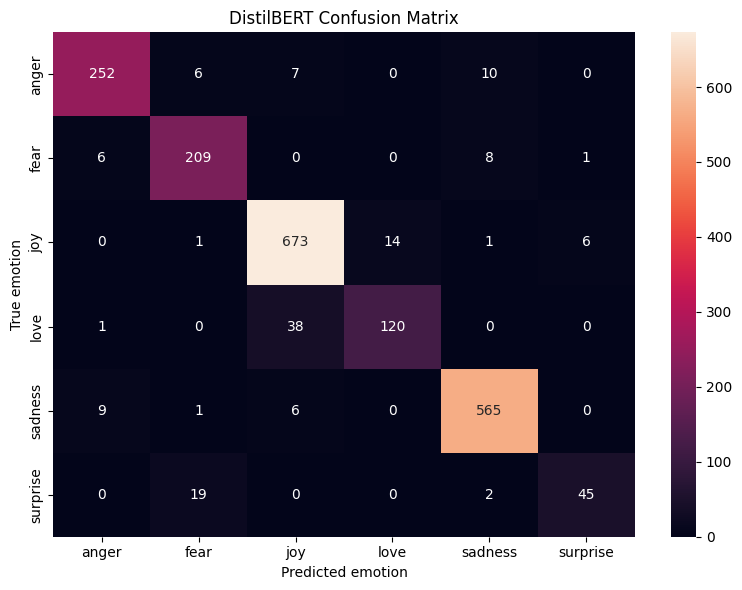

In [37]:
matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=label_ids
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted emotion")
plt.ylabel("True emotion")
plt.title("DistilBERT Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "results/distilbert_confusion_matrix.png"
)

plt.show()

In [39]:
torch.save(
    best_model.state_dict(),
    "results/best_distilbert_model.pt"
)

### Analiza rezultata

Najbolja DistilBERT konfiguracija koristi learning rate `5e-5`, batch size `16` i najbolji rezultat postiže nakon 3 epohe.

Na test skupu model postiže Accuracy od `TEST_ACCURACY` i Macro F1 od `TEST_MACRO_F1`.

Najbolji rezultati ostvareni su za klase koje imaju najveći broj primera u trening skupu, dok se slabiji rezultati mogu očekivati kod manjinskih klasa `love` i `surprise`.

Macro F1 je posebno važna metrika zbog neuravnotežene raspodele klasa, jer svim klasama daje jednak značaj bez obzira na broj primera.

DistilBERT postiže veoma slične validation rezultate kao BERT, iako je manji i računarski efikasniji model.